# KenLM: 3-Gram General + Domain-Specific

## Setup

In [1]:
import kenlm
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import os
import random

In [2]:
os.environ['PATH'] = "/home/lawun330/NLP/SRILM/bin/i686-m64:" + os.environ['PATH']
!echo $PATH

/home/lawun330/NLP/SRILM/bin/i686-m64:/home/lawun330/anaconda3/envs/lu_burmese_domain_specific_lm_env/bin:/home/lawun330/.local/bin:/home/lawun330/.config/herd-lite/bin:/home/lawun330/.cargo/bin:/home/lawun330/.local/bin:/home/lawun330/.nvm/versions/node/v22.22.2/bin:/home/lawun330/anaconda3/condabin:/home/lawun330/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin


In [3]:
ROOT = Path("..").resolve()

# paths
TRAIN_DIR = ROOT / "data" / "train" / "domain-specific"
KENLM_DIR = ROOT / "models" / "kenlm"
TMP_DIR = KENLM_DIR / "tmp"
PPL_DIR = KENLM_DIR / "ppl"

# general kenlm model
GENERAL_LM = KENLM_DIR / "kenlm_3gram.arpa"

# domain-specific training data
TRAIN_NEWS_NO_SPLIT = TRAIN_DIR / "train_news.cleaned.state3"
TRAIN_LEGAL_NO_SPLIT = TRAIN_DIR / "train_legal.cleaned.state3"
TRAIN_RELIGION_NO_SPLIT = TRAIN_DIR / "train_religion.cleaned.state3"

# splitted domain-specific training data
## news: train_news.cleaned.state3 is split into
## - train_news.train and
## - train_news.dev
NEWS_TRAIN = TRAIN_DIR / "train_news.train"
NEWS_DEV = TRAIN_DIR / "train_news.dev"

# legal: train_legal.cleaned.state3 is split into
# - train_legal.train and
# - train_legal.dev
LEGAL_TRAIN = TRAIN_DIR / "train_legal.train"
LEGAL_DEV = TRAIN_DIR / "train_legal.dev"

# religion: train_religion.cleaned.state3 is split into
# - train_religion.train and
# - train_religion.dev
RELIGION_TRAIN = TRAIN_DIR / "train_religion.train"
RELIGION_DEV = TRAIN_DIR / "train_religion.dev"

# domain-specific test data
NEWS_TEST = ROOT / "data" / "test" / "news.cleaned.state4"
LEGAL_TEST = ROOT / "data" / "test" / "legal.cleaned.state4"
RELIGION_TEST = ROOT / "data" / "test" / "religion.cleaned.state4"

ORDER = 3

CORPORA = [
    ("news", NEWS_TEST),
    ("legal", LEGAL_TEST),
    ("religion", RELIGION_TEST),
]

EVAL_SCRIPT = ROOT / "eval_kenlm_srilm.py"

sys.path.insert(0, str(ROOT))
import eval_kenlm_srilm

## Split All Datasets

### News: Train & Dev Datasets

In [4]:
lines = [ln.strip() for ln in TRAIN_NEWS_NO_SPLIT.read_text(encoding="utf-8").splitlines() if ln.strip()]

random.seed(42)
random.shuffle(lines)

n = len(lines)
mid = n // 2
train_lines = lines[:mid]
dev_lines = lines[mid:]

NEWS_TRAIN.write_text("\n".join(train_lines) + ("\n" if train_lines else ""), encoding="utf-8")
NEWS_DEV.write_text("\n".join(dev_lines) + ("\n" if dev_lines else ""), encoding="utf-8")

print(n, "non-empty lines ->", len(train_lines), "train,", len(dev_lines), "dev")

11 non-empty lines -> 5 train, 6 dev


### Legal: Train & Dev Datasets

In [5]:
lines = [ln.strip() for ln in TRAIN_LEGAL_NO_SPLIT.read_text(encoding="utf-8").splitlines() if ln.strip()]

random.seed(42)
random.shuffle(lines)

n = len(lines)
mid = n // 2
train_lines = lines[:mid]
dev_lines = lines[mid:]

LEGAL_TRAIN.write_text("\n".join(train_lines) + ("\n" if train_lines else ""), encoding="utf-8")
LEGAL_DEV.write_text("\n".join(dev_lines) + ("\n" if dev_lines else ""), encoding="utf-8")

print(n, "non-empty lines ->", len(train_lines), "train,", len(dev_lines), "dev")

149 non-empty lines -> 74 train, 75 dev


### Religion: Train & Dev Datasets

In [6]:
lines = [ln.strip() for ln in TRAIN_RELIGION_NO_SPLIT.read_text(encoding="utf-8").splitlines() if ln.strip()]

random.seed(42)
random.shuffle(lines)

n = len(lines)
mid = n // 2
train_lines = lines[:mid]
dev_lines = lines[mid:]

RELIGION_TRAIN.write_text("\n".join(train_lines) + ("\n" if train_lines else ""), encoding="utf-8")
RELIGION_DEV.write_text("\n".join(dev_lines) + ("\n" if dev_lines else ""), encoding="utf-8")

print(n, "non-empty lines ->", len(train_lines), "train,", len(dev_lines), "dev")

213 non-empty lines -> 106 train, 107 dev


## Domain-Specific KenLMs

### News KenLM

In [7]:
news_arpa = f"{KENLM_DIR}/kenlm_3gram_news.arpa"

In [8]:
!cat {NEWS_TRAIN} | lmplz -o {ORDER} -S 4G -T {TMP_DIR} --discount_fallback > {news_arpa} 2>{news_arpa}.error

In [9]:
!head -15 {news_arpa}

\data\
ngram 1=354
ngram 2=850
ngram 3=1010

\1-grams:
-2.9018545	<unk>	0
0	<s>	-0.07040735
-2.6447067	</s>	0
-2.774012	Scrabble	-0.07040732
-2.2489405	လို့	-0.11272749
-2.774012	ခေါ်	-0.07040732
-1.8963339	တဲ့	-0.1256171
-2.774012	စာ	-0.07040732
-2.6447067	လုံး	-0.07040732


In [10]:
!cat {news_arpa}.error

=== 1/5 Counting and sorting n-grams ===
File stdin isn't normal.  Using slower read() instead of mmap().  No progress bar.
Unigram tokens 1155 types 354
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:4248 2:1493900160 3:2801062912
Statistics:
1 354 D1=0.635294 D2=1.13928 D3+=2.27395
2 850 D1=0.85034 D2=1.22696 D3+=2.14966
3 1010 D1=0.875598 D2=1.23217 D3+=1.89398
Memory estimate for binary LM:
type    kB
probing 46 assuming -p 1.5
probing 53 assuming -r models -p 1.5
trie    21 without quantization
trie    17 assuming -q 8 -b 8 quantization 
trie    21 assuming -a 22 array pointer compression
trie    16 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:4248 2:13600 3:20200
=== 4/5 Calculating and writing order-interpolated probabilities ===
Chain sizes: 1:4248 2:13600 3:20200
=== 5/5 Writing ARPA model ===
Name:lmplz	VmPeak:4342500 kB	VmRSS:6132 kB	RSSMax:970724 kB	user:0.108

### Legal KenLM 

In [11]:
legal_arpa = f"{KENLM_DIR}/kenlm_3gram_legal.arpa"

In [12]:
!cat {LEGAL_TRAIN} | lmplz -o {ORDER} -S 4G -T {TMP_DIR} --discount_fallback > {legal_arpa} 2>{legal_arpa}.error

In [13]:
!head -15 {legal_arpa}

\data\
ngram 1=365
ngram 2=1121
ngram 3=1568

\1-grams:
-3.0091496	<unk>	0
0	<s>	-0.2414797
-1.8744526	</s>	0
-2.647841	၃၃	-0.094503954
-2.0094929	က	-0.19936
-1.7951148	ပြည်	-0.49988174
-2.8850543	ထဲ	-0.094503954
-1.936745	ရေး	-0.19194557
-2.2065206	ဝန်	-0.24511103


In [14]:
!cat {legal_arpa}.error

=== 1/5 Counting and sorting n-grams ===
File stdin isn't normal.  Using slower read() instead of mmap().  No progress bar.
Unigram tokens 2874 types 365
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:4380 2:1493900160 3:2801062912
Statistics:
1 365 D1=0.636964 D2=0.575518 D3+=2.13
2 1121 D1=0.804444 D2=0.815273 D3+=1.987
3 1568 D1=0.728662 D2=1.17897 D3+=1.14191
Memory estimate for binary LM:
type    kB
probing 63 assuming -p 1.5
probing 71 assuming -r models -p 1.5
trie    27 without quantization
trie    19 assuming -q 8 -b 8 quantization 
trie    27 assuming -a 22 array pointer compression
trie    19 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:4380 2:17936 3:31360
=== 4/5 Calculating and writing order-interpolated probabilities ===
Chain sizes: 1:4380 2:17936 3:31360
=== 5/5 Writing ARPA model ===
Name:lmplz	VmPeak:4350696 kB	VmRSS:6184 kB	RSSMax:968876 kB	user:0.1413

### Religion KenLM

In [15]:
religion_arpa = f"{KENLM_DIR}/kenlm_3gram_religion.arpa"

In [16]:
!cat {RELIGION_TRAIN} | lmplz -o {ORDER} -S 4G -T {TMP_DIR} --discount_fallback > {religion_arpa} 2>{religion_arpa}.error

In [17]:
!head -15 {religion_arpa}

\data\
ngram 1=377
ngram 2=1056
ngram 3=1221

\1-grams:
-3.0984535	<unk>	0
0	<s>	-0.23596208
-1.2613904	</s>	0
-2.569427	ဝါ	-0.5155739
-2.8504303	ယော	-0.07473341
-1.6648535	သည်	-0.156854
-2.8504303	တွန်း	-0.07473341
-2.8504303	ကန်	-0.07473341
-2.569427	လှုပ်	-0.07473341


In [18]:
!cat {religion_arpa}.error

=== 1/5 Counting and sorting n-grams ===
File stdin isn't normal.  Using slower read() instead of mmap().  No progress bar.
Unigram tokens 1432 types 377
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:4524 2:1493900032 3:2801062656
Statistics:
1 377 D1=0.596491 D2=1.35164 D3+=0.99579
2 1056 D1=0.841912 D2=1.38325 D3+=0.915266
3 1221 D1=0.812643 D2=1.68287 D3+=1.17155
Memory estimate for binary LM:
type    kB
probing 55 assuming -p 1.5
probing 63 assuming -r models -p 1.5
trie    25 without quantization
trie    19 assuming -q 8 -b 8 quantization 
trie    25 assuming -a 22 array pointer compression
trie    18 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:4524 2:16896 3:24420
=== 4/5 Calculating and writing order-interpolated probabilities ===
Chain sizes: 1:4524 2:16896 3:24420
=== 5/5 Writing ARPA model ===
Name:lmplz	VmPeak:4350696 kB	VmRSS:6116 kB	RSSMax:970724 kB	user:0.

### ARPA to Binary

In [19]:
!build_binary {news_arpa} {news_arpa}.binary
!build_binary {legal_arpa} {legal_arpa}.binary
!build_binary {religion_arpa} {religion_arpa}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_news.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS
Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_legal.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS
Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_religion.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


## General + News KenLM

In [20]:
GEN_LM_DEV = f"{PPL_DIR}/gen_lm_on_dev_news.ppl"
DOMAIN_LM_DEV = f"{PPL_DIR}/domain_lm_on_dev_news.ppl"

In [21]:
# general LM on domain-specific development dataset
!ngram -order {ORDER} -lm {GENERAL_LM} -ppl {NEWS_DEV} -debug 2 > {GEN_LM_DEV}

# domain LM on domain-specific development dataset
!ngram -order {ORDER} -lm {news_arpa} -ppl {NEWS_DEV} -debug 2 > {DOMAIN_LM_DEV}

# tune λ
!compute-best-mix {GEN_LM_DEV} {DOMAIN_LM_DEV}

reading 9212 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 194722 2-grams
reading 663922 3-grams
reading 354 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_news.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 850 2-grams
reading 1010 3-grams
iteration 1, lambda = (0.5 0.5), ppl = 53.4972
iteration 2, lambda = (0.585672 0.414328), ppl = 52.3198
iteration 3, lambda = (0.628834 0.371166), ppl = 52.0127
iteration 4, lambda = (0.650877 0.349123), ppl = 51.9296
iteration 5, lambda = (0.662328 0.337672), ppl = 51.9066
iteration 6, lambda = (0.668347 0.331653), ppl = 51.9002
iteration 7, lambda = (0.671532 0.328468), ppl = 51.8983
iteration 8, lambda = (0.673224 0.326776), ppl = 51.8978
6703 non-oov words, best lambda (0.674125 0.325875)
pairwise cumulative lambda (1 0.325875)


In [22]:
# mix general and news LMs
COMBINED_LM = f"{KENLM_DIR}/kenlm_3gram_general_plus_news.arpa"
lambda_for_gen_lm = 0.674125  ## -- UPDATE HERE --
!ngram -order {ORDER} -lm {GENERAL_LM} -mix-lm {news_arpa} -lambda {lambda_for_gen_lm} -write-lm {COMBINED_LM}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_news.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
BOW numerator for context "" is -1 < 0


In [23]:
# ARPA to Binary
!build_binary {COMBINED_LM} {COMBINED_LM}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_general_plus_news.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


## General + Legal KenLM

In [24]:
GEN_LM_DEV = f"{PPL_DIR}/gen_lm_on_dev_legal.ppl"
DOMAIN_LM_DEV = f"{PPL_DIR}/domain_lm_on_dev_legal.ppl"

In [25]:
# general LM on domain-specific development dataset
!ngram -order {ORDER} -lm {GENERAL_LM} -ppl {LEGAL_DEV} -debug 2 > {GEN_LM_DEV}

# domain LM on domain-specific development dataset
!ngram -order {ORDER} -lm {legal_arpa} -ppl {LEGAL_DEV} -debug 2 > {DOMAIN_LM_DEV}

# tune λ
!compute-best-mix {GEN_LM_DEV} {DOMAIN_LM_DEV}

reading 9212 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 194722 2-grams
reading 663922 3-grams
reading 365 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_legal.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 1121 2-grams
reading 1568 3-grams
iteration 1, lambda = (0.5 0.5), ppl = 10.0658
iteration 2, lambda = (0.340045 0.659955), ppl = 9.28543
iteration 3, lambda = (0.255759 0.744241), ppl = 9.04893
iteration 4, lambda = (0.211363 0.788637), ppl = 8.97284
iteration 5, lambda = (0.187248 0.812752), ppl = 8.9475
iteration 6, lambda = (0.173758 0.826242), ppl = 8.93889
iteration 7, lambda = (0.166048 0.833952), ppl = 8.93592
iteration 8, lambda = (0.16158 0.83842), ppl = 8.93489
iteration 9, lambda = (0.158966 0.841034), ppl = 8.93453
iteration 10, lambda = (0.15743 0.84257), ppl = 8.9344
2895

In [26]:
# mix general and legal LMs
COMBINED_LM = f"{KENLM_DIR}/kenlm_3gram_general_plus_legal.arpa"
lambda_for_gen_lm = 0.156523  ## -- UPDATE HERE --
!ngram -order {ORDER} -lm {GENERAL_LM} -mix-lm {legal_arpa} -lambda {lambda_for_gen_lm} -write-lm {COMBINED_LM}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_legal.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
BOW numerator for context "" is -1 < 0


In [27]:
# ARPA to Binary
!build_binary {COMBINED_LM} {COMBINED_LM}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_general_plus_legal.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


## General + Religion KenLM

In [28]:
GEN_LM_DEV = f"{PPL_DIR}/gen_lm_on_dev_religion.ppl"
DOMAIN_LM_DEV = f"{PPL_DIR}/domain_lm_on_dev_religion.ppl"

In [29]:
# general LM on domain-specific development dataset
!ngram -order {ORDER} -lm {GENERAL_LM} -ppl {RELIGION_DEV} -debug 2 > {GEN_LM_DEV}

# domain LM on domain-specific development dataset
!ngram -order {ORDER} -lm {religion_arpa} -ppl {RELIGION_DEV} -debug 2 > {DOMAIN_LM_DEV}

# tune λ
!compute-best-mix {GEN_LM_DEV} {DOMAIN_LM_DEV}

reading 9212 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 194722 2-grams
reading 663922 3-grams
reading 377 1-grams
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_religion.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
reading 1056 2-grams
reading 1221 3-grams
iteration 1, lambda = (0.5 0.5), ppl = 76.7218
iteration 2, lambda = (0.344261 0.655739), ppl = 71.4676
iteration 3, lambda = (0.278075 0.721925), ppl = 70.427
iteration 4, lambda = (0.248516 0.751484), ppl = 70.1954
iteration 5, lambda = (0.234612 0.765388), ppl = 70.1406
iteration 6, lambda = (0.227865 0.772135), ppl = 70.1272
iteration 7, lambda = (0.224535 0.775465), ppl = 70.1239
iteration 8, lambda = (0.222877 0.777123), ppl = 70.1231
1494 non-oov words, best lambda (0.222048 0.777952)
pairwise cumulative lambda (1 0.777952)


In [30]:
# mix general and religion LMs
COMBINED_LM = f"{KENLM_DIR}/kenlm_3gram_general_plus_religion.arpa"
lambda_for_gen_lm = 0.222048  ## -- UPDATE HERE --
!ngram -order {ORDER} -lm {GENERAL_LM} -mix-lm {religion_arpa} -lambda {lambda_for_gen_lm} -write-lm {COMBINED_LM}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
/home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_religion.arpa: line 7: warning: non-zero probability for <unk> in closed-vocabulary LM
BOW numerator for context "" is -1 < 0


In [31]:
# ARPA to Binary
!build_binary {COMBINED_LM} {COMBINED_LM}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram_general_plus_religion.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


## Model Loading

In [32]:
# load only binary models

try:
    # general LM
    general_lm = kenlm.LanguageModel(f"{GENERAL_LM}.binary")

    # domain LMs
    domain_lm_news = kenlm.LanguageModel(f"{news_arpa}.binary")
    domain_lm_legal = kenlm.LanguageModel(f"{legal_arpa}.binary")
    domain_lm_religion = kenlm.LanguageModel(f"{religion_arpa}.binary")

    # general + domain LMs
    combined_lm_news = kenlm.LanguageModel(f"{KENLM_DIR}/kenlm_3gram_general_plus_news.arpa.binary")
    combined_lm_legal = kenlm.LanguageModel(f"{KENLM_DIR}/kenlm_3gram_general_plus_legal.arpa.binary")
    combined_lm_religion = kenlm.LanguageModel(f"{KENLM_DIR}/kenlm_3gram_general_plus_religion.arpa.binary")

    print("Models loaded successfully.")

except Exception as e:
    print(f"Error loading models: {e}")

Models loaded successfully.


In [33]:
MODELS = [
    ("general", general_lm),
    ("news", domain_lm_news),
    ("legal", domain_lm_legal),
    ("religion", domain_lm_religion),
    ("general_plus_news", combined_lm_news),
    ("general_plus_legal", combined_lm_legal),
    ("general_plus_religion", combined_lm_religion),
]

## Model Evaluation

In [34]:
rows = []
for corpus_name, corpus_path in CORPORA:
    row = {"corpus": corpus_name}
    for tag, model in MODELS:
        ppl, ent, bpc = eval_kenlm_srilm.evaluate(model, corpus_path)
        row[f"ppl_{tag}"] = ppl
        row[f"ent_{tag}"] = ent
        row[f"bpc_{tag}"] = bpc
    rows.append(row)

In [35]:
df_eval = pd.DataFrame(rows).set_index("corpus")
df_eval

,ppl_general,ent_general,bpc_general,ppl_news,ent_news,bpc_news,ppl_legal,ent_legal,bpc_legal,ppl_religion,...,bpc_religion,ppl_general_plus_news,ent_general_plus_news,bpc_general_plus_news,ppl_general_plus_legal,ent_general_plus_legal,bpc_general_plus_legal,ppl_general_plus_religion,ent_general_plus_religion,bpc_general_plus_religion
corpus,,,,,,,,,,,,,,,,,,,,,
news,115.336455,4.747854,1.770022,233.487727,5.453130,2.032952,490.722574,6.195879,2.309853,500.196819,...,2.316982,106.186368,4.665196,1.739207,268.399907,5.592478,2.084902,195.826626,5.277230,1.967376
legal,187.541371,5.233999,1.956074,405.842456,6.005965,2.244576,160.430344,5.077860,1.897720,384.769676,...,2.224649,173.601270,5.156761,1.927208,117.825925,4.769208,1.782370,241.120243,5.485296,2.049989
religion,559.033929,6.326210,2.372062,318.159108,5.762552,2.160714,313.915011,5.749122,2.155679,45.793051,...,1.433889,327.018933,5.790018,2.171013,411.764160,6.020451,2.257415,52.917141,3.968727,1.488106


## Visualization

In [36]:
mix_suffix = {
    "news": "general_plus_news",
    "legal": "general_plus_legal",
    "religion": "general_plus_religion",
}

metrics = [
    ("ppl", "Perplexity (PPL)", True),   # log scale
    ("ent", "Entropy (nats)", False),
    ("bpc", "Bits per character (BPC)", False),
]

x = np.arange(len(df_eval.index))
w = 0.25
offsets = np.array([-w, 0.0, w])
labels_bar = ["General", "Domain only", "Mixed"]
colors = ["#AEB8C6", "#1E4FA8", "#191970"]

saved: /home/lawun330/Desktop/burmese-domain-specific-lm/img/kenlm_general_domain_mix_metrics.png


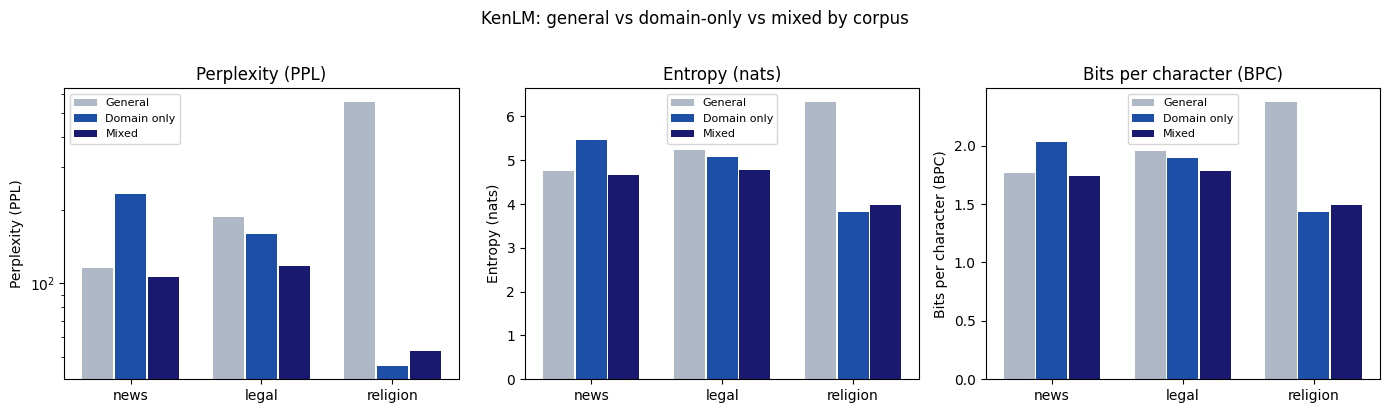

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (prefix, ylabel, use_log) in zip(axes, metrics):
    gen_vals = []
    dom_vals = []
    mix_vals = []
    for corpus in df_eval.index:
        gen_vals.append(df_eval.loc[corpus, f"{prefix}_general"])
        dom_vals.append(df_eval.loc[corpus, f"{prefix}_{corpus}"])
        mix_vals.append(df_eval.loc[corpus, f"{prefix}_{mix_suffix[corpus]}"])
    for off, vals, lab, c in zip(
        offsets,
        [gen_vals, dom_vals, mix_vals],
        labels_bar,
        colors,
    ):
        ax.bar(x + off, vals, width=w * 0.95, label=lab, color=c)
    ax.set_xticks(x, list(df_eval.index))
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(loc="best", fontsize=8)
    if use_log:
        ax.set_yscale("log")

fig.suptitle("KenLM: general vs domain-only vs mixed by corpus", y=1.02)
plt.tight_layout()

out_path = ROOT / "img" / "kenlm_general_domain_mix_metrics.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("saved:", out_path)

plt.show()

## Conclusion

### Model-Wise

The mixed model performs better in its corresponding domain, as reflected by:

- lower perplexity
- lower entropy
- lower bits-per-character

Although the mixed model performs slightly worse than the domain-only model on the religion domain, its performance is still comparable and the difference is small.